## **Домашнее задание: Градиентный спуск — базовые концепции**


В этом домашнем задании вы попрактикуетесь в двух вещах:

1. **Градиентный спуск**
   Вы реализуете базовый GD, закрепите на практике его свойства и научитесь интерпретировать результаты.

2. **Дебаггинг**
   По ходу выполнения заданий вам потребуется выявлять и исправлять ошибки — в паре мест — в программной реализации.

##### **Почему дебаггинг?**

На практике, особенно часто при работе с обучением моделей придется читать ошибки и обеспечивать совместимость своего кода с написанным ранее. При этом, написанный ранее код может быть написан не идеально — не важно LLM его писала или человек.

В этом домашнем задании вы:

* реализуете класс GD с треккингом лосса и градиентов;
* проверите, корректно ли ваш оптимизатор работает на разных функциях (в том числе на не выпуклых!);
* потренируетесь читать графики loss;
* получите много красивых визуализаций;

**Ошибки только в функции для графиков!**

**Дедлайн: 13 декабря 23:59**



In [55]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import pandas as pd

np.random.seed(42)

### **Функция для картинок**

Эта функция для красивых графиков. Разберитесь в ее работе (можно - при помощи LLM).

<font color="red">В функции в двух местах преднамеренно допущены ошибки. Исправьте их. </font>

In [56]:
# Эта функция для красивых графиков
def plot_gd_3d(x_range, y_range, Z, loss_fn, history_dict,
               title="Градиентный спуск (3D)", min_point=None):
    """
    3D-график: поверхность + траектории градиентного спуска.

    x_range, y_range : 1D np.array
        Диапазоны по осям x и y.
    Z : 2D np.array
        Значения функции на сетке (len(y_range), len(x_range)).
    loss_fn : callable
        Функция потерь f(params) -> float, чтобы считать z вдоль траекторий. ->


        смотрим сюда, сравниваем с z_traj = ... и понимаем, что x_range(p)
        это, во-первых, попытка передать аргумент в массив как в функцию, что
        достаточно странно и не будет работать, а, во-вторых, это нужно заменить
        на подсчёт z через вычисление значения функции потерь, так как высота z
        это по сути и есть величина лосса в точке (x, y).


    history_dict : dict[str, history]
        Словарь: метка -> history, где history['params'] — список параметров.
        Например: {"LR=0.1": gd.history, "LR=0.01": gd2.history}
    min_point : tuple (x*, y*) или None
        Если задано, отмечаем минимум на графике.
    """
    fig = go.Figure()

    # Поверхность функции
    fig.add_trace(
        go.Surface(
            x=x_range,
            y=y_range,
            z=Z,
            opacity=0.7,
            showscale=False
        )
    )

    # Траектории
    # считаются по лоссу
    for label, history in history_dict.items():
        trajectory = np.array(history["params"])  # shape: (T, 2)
        x_traj = trajectory[:, 0]
        y_traj = trajectory[:, 1]
        z_traj = np.array([loss_fn(p) for p in trajectory])
        # было: z_traj = np.array([x_range(p) for p in trajectory])

        fig.add_trace(
            go.Scatter3d(
                x=x_traj,
                y=y_traj,
                z=z_traj,
                mode='lines+markers',
                name=label,
                marker=dict(size=4),
                line=dict(width=4)
            )
        )

    # Минимум, если задан
    if min_point is not None:
        x_min, y_min = min_point
        fig.add_trace(
            go.Scatter3d(
                x=[x_min],
                y=[y_min],
                z=[loss_fn(np.array([x_min, y_min]))],
                mode='markers',
                name='Минимум',
                marker=dict(size=6, symbol='diamond-open')
            )
        )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="x",
            yaxis_title="y",
            zaxis_title="f(x, y)"
        ),
        height=700
    )

    fig.show()


def plot_gd_2d(x_range, y_range, Z, history_dict,
               title="Градиентный спуск (2D контуры)",
               start_points=None, min_point=None,
               contour_kwargs=None):
    """
    2D-контуры + траектории градиентного спуска.

    x_range, y_range : 1D np.array
    Z : 2D np.array
    history_dict : dict[str, history]
        метка -> history, где history['params'] — список параметров.
    start_points : list[np.array] или None
        Список стартовых точек (x0, y0), чтобы нарисовать их на графике.
    min_point : tuple (x*, y*) или None
        Если задано, отмечаем минимум.
    contour_kwargs : dict или None
        Доп. параметры для go.Contour (contours=..., opacity=..., ...).
    """
    if contour_kwargs is None:
        contour_kwargs = dict(
            colorscale='Viridis',
            showscale=False,
            contours=dict(start=0, end=30, size=2),
            opacity=0.7
        )

    fig = go.Figure()

    # Контурный график функции
    fig.add_trace(
        go.Contour(
            x=x_range,
            y=y_range,
            z=Z,
            **contour_kwargs
        )
    )

    # Траектории
    for label, history in history_dict.items():
        trajectory = np.array(history["params"])
        fig.add_trace(
            go.Scatter(
                x=trajectory[:, 0],
                y=trajectory[:, 1],
                mode='lines+markers',
                name=label,
                marker=dict(size=5),
                line=dict(width=3)
            )
        )

    # Стартовые точки (если переданы отдельно)
    # точка имеет
    if start_points is not None:
        for i, p0 in enumerate(start_points):
            fig.add_trace(
                go.Scatter(
                    x=[p0[0]],
                    # y=[p0[0]], <- вряд ли мы хотим рисовать все стартовые
                    # точки только по диагонали. Нужно брать второй элемент
                    # (с индексом 1) отдельно
                    y = [p0[1]],
                    mode='markers',
                    name=f'Start {i+1}',
                    marker=dict(size=10, symbol='x')
                )
            )

    # Минимум
    if min_point is not None:
        x_min, y_min = min_point
        fig.add_trace(
            go.Scatter(
                x=[x_min],
                y=[y_min],
                mode='markers',
                name='Минимум',
                marker=dict(size=10, symbol='diamond-open')
            )
        )

    fig.update_layout(
        title=title,
        xaxis_title="x",
        yaxis_title="y",
        height=700
    )

    fig.show()

### **Задание 1. Градиентный спуск: постановка задачи (3 балла)**


Напомним, что в задачах машинного обучения мы хотим минимизировать **функцию потерь**
$$L(w): \mathbb{R}^d \to \mathbb{R},$$
где $w \in \mathbb{R}^d$ — вектор параметров модели (веса), а $L$ измеряет качество этой модели на данных. Пострейший пример функции потерь — MSE потери. Если мы обозначим за $y_i$ истинный прогноз, а за $\hat{y}$ — предсказанный моделью, то MSE — функция вида:

$$L(\hat{y}, y) = \frac{1}{n}\sum_{i=1}^{n} (y - \hat{y})^2$$

Если функция потерь дифференцируема, один из базовых численных методов для её минимизации — **градиентный спуск** (Gradient Descent). Если же функция потерь дифференцируема не везде — мы используем в "плохих точках" [субградиент](https://www.google.com/search?client=safari&rls=en&q=%D0%A1%D1%83%D0%B1%D0%B3%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82&ie=UTF-8&oe=UTF-8).

#### **Идея метода градиетного спуска**

Градиент $\nabla L(w)$ по определению показывает направление **наискорейшего роста** функции. Чтобы уменьшать значение $L(w)$, нужно двигаться в противоположную сторону — туда, где функция убывает:

$$w_{k+1} = w_k - \eta \nabla L(w_k),$$

где

* $w_k$ — параметры на итерации $k$,
* $\eta > 0$ — шаг обучения (learning rate),
* $\nabla L(w_k)$ — градиент функции потерь по параметрам $w$ в точке $w_k$.

При достаточно «хороших» свойствах $L(w)$ (выпуклость — можно обозвать это "парабольным" поведением и гладкость — дифференцируемость везде) и правильно подобранном шаге $\eta$ последовательность ${w_k}$ будет стремиться к точке минимума. На практике, свойства функции мы проверяем не всегда, так как используем золотой набор функций устоявшийся в области и ключевую роль играет шаг $\eta$.

#### **Детали? Детали!**

При реализации градиентного спуска нужно учитывать:

1. **Инициализацию**

   Необходимо задать начальное значение параметров $w_0$.

2. **Шаг обучения $\eta$**

     Его правильный подбор — это искусство.

3. **Критерии остановки**

   Обычно метод выполняется фиксированное число итераций $N$, либо пока не выполнится одно из условий:

   * $|\nabla L(w_k)|$ стало достаточно малым;
   * изменение параметров $|w_{k+1} - w_k|$ мало;
   * изменение значения потерь $|L(w_{k+1}) - L(w_k)|$ мало.

4. **История обучения**

   Для анализа работы алгоритма полезно сохранять:

   * значения параметров $w_k$ на каждой итерации;
   * значения функции потерь $L(w_k)$;
   * (не обязательно, но полезно) значения нормы градиента $|\nabla L(w_k)|$.

    Эта информация позволит визуализировать траекторию спуска и поведение loss-функции во времени. Когда у нас есть этот график (да и вообще все 3 из перечисленных), мы можем понимать, как у обучения дела.


#### **1. Выпуклость и нет (1.5 балла)**

Из теории мы также знаем, что хочется минимизировать **выпуклые функции**. Почему именно их? Они приятные и у них:

* либо один глобальный минимум,
* либо целое выпуклое множество глобальных минимумов,
* нет локальных минимумов.

Это означает, что при разумном шаге градиентный спуск, стартуя из любой точки, будет стремиться к глобальному минимуму.

Формально, функция $f:\mathbb{R}^d \to \mathbb{R}$ называется **выпуклой**, если для любых $x, y \in \mathbb{R}^d$ и $\lambda \in [0, 1]$:
$$f(\lambda x + (1-\lambda) y) \leq \lambda f(x) + (1-\lambda) f(y)$$

Для дважды дифференцируемых функций это эквивалентно тому, что их **матрица Гессе** (матрица вторых производных) неотрицательно определена во всех точках.

Но это всё детали. Которые полезно знать. Но в реальных задачах машинного обучения мы почти всегда сталкиваемся с **невыпуклыми** функциями потерь.

Уметь понимать поведение на выпуклом и невыпуклом ландшафте по лоссу/градиенту важно, потому что это поможет вам в будущем изучать графики ваших моделей более четко и понимать, почему обучение застряло и что с этим можно сделать (добавить инерцию, перестартануть с других точек и так далее). Что же, давайте знакомиться с разным поведением!

#### **1. 1. Задание: реализуйте в коде функции и их градиенты**

1. **Простая квадратичная функция** (выпуклая):
   
   $f(x, y) = x^2 + y^2.$

2. **Функция Розенброка ([Rosenbrock's banana function](https://ru.wikipedia.org/wiki/%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F_%D0%A0%D0%BE%D0%B7%D0%B5%D0%BD%D0%B1%D1%80%D0%BE%D0%BA%D0%B0))**:

   $f_{\text{R}}(x, y) = (a - x)^2 + b(y - x^2)^2$, тут по умолчанию a=1, b=100, но далее надо реализовывать a и b как гиперпараметры.

Мы будем использовать эти функции дальше для визуализации траекторий градиентного спуска, сравнения влияния шага обучения и анализа ландшафта.

**Ваши задачи в этом подпункте:**

1. Реализовать функции:

   * `quadratic_loss(params)`
   * `rosenbrock_loss(params, a=1, b=100)`

2. Реализовать их градиенты:

   * `quadratic_grad(params)` — возвращает `[grad_x, grad_y]`
   * `rosenbrock_grad(params, a=1, b=100)` — возвращает `[grad_x, grad_y]`


Дальше эти функции будут использоваться в классе `GradientDescent` для экспериментов с разными значениями шага обучения и для 2D/3D визуализаций ландшафта.



In [57]:
# Квадратичная функция
def quadratic_loss(params):
    """
    params: list — список, вида [x, y]
    f(x, y) = x^2 + y^2
    """
    x, y = params

    return x**2 + y**2

def quadratic_grad(params):
    """Градиент"""
    x, y = params
    grad_x = 2 * x
    grad_y = 2 * y

    return np.array([grad_x, grad_y])

# Функция Розенброка
def rosenbrock_loss(params, a=1, b=100):
    """
    params: list — список, вида [x, y]
    f(x, y) = (a - x)^2 + b(y - x^2)^2
    """
    x, y = params

    return (a - x)**2 + b * (y - x**2)**2

def rosenbrock_grad(params, a=1, b=100):
    """Градиент функции Розенброка"""
    x, y = params
    # по x: -2(a - x) - 4bx(y - x^2)
    grad_x = -2 * (a - x) - 4 * b * x * (y - x**2)
    # по y: 2b(y - x^2)
    grad_y = 2 * b * (y - x**2)

    return np.array([grad_x, grad_y])


#### **1. 2. Реализуйте классический (ванильный) градиентный спуск (1.5 балла)**

Теперь давайте сделаем **класс градиентного спуска** `GradientDescent`, в котором будет помимо прочего реализовано подробное логирование. Все параметры, которые класс принимает на вход, описаны ниже и соответствуют теоретической постановке задачи.

In [58]:
class GradientDescent:

    """Ваш класс для базовой реализации градиентного спуска
    learning_rate: float - скорость спуска
    n_iterations: int - максимальное количество итераций спуска
    history: dict - словарь, который будет хранить историю обучения
    """

    # Ваш код здесь
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate # просто подставляем значения,
        self.n_iterations = n_iterations # переданные при создании экземпляра класса
        self.history = {
            'params': [],
            'loss': [],
            'gradients': []
        }

    def fit(self, loss_fn, grad_fn, initial_params):
        """
        Обучение с помощью GD

            loss_fn: функция потерь
            grad_fn: функция градиента
            initial_params: начальные параметры
        """
        # params = initial_params.copy()
        # вот здесь очень хочется, чтобы параметры были нампай массивом,
        # чтобы мы могли работать со всеми переменными в векторном виде,
        # поэтому:
        params = np.array(initial_params, dtype=float).copy()

        for i in range(self.n_iterations):
            # Вычисляем градиент
            grad = grad_fn(params)
            loss = loss_fn(params)

            # Сохраняем историю
            self.history['params'].append(params.copy())
            self.history['loss'].append(loss)
            self.history['gradients'].append(grad.copy())

            # Обновляем параметры
            params = params - self.learning_rate * grad
            # правда ведь так понятнее, чем при params НЕ нампай массиве
            # params = [p - lr * g for p, g in zip(params, grad)]

        # Сохраняем финальное состояние
        self.history['params'].append(params.copy())
        self.history['loss'].append(loss_fn(params))
        self.history['gradients'].append(grad_fn(params))

        return params


Теперь проверим работоспособность функций, но если вы сделали это выше при реализации — вам только плюсы!

Мы будем использовать библиотеку plotly, чтобы получить функциональные графики — которые можно приближать, отдалять, крутить и так далее. Нарисуем полученные функции в 3D и протестируем градиентный спуск. Вернее, его параметры.

### **Задание 2. Анализ гиперпараметров градиетного спуска (2 балла)**


Learning rate (в разных нотациях его обозначают за $\eta или \alpha$) — основной гиперпараметр градиетного спуска и любой его модификации. Даже для простой выпуклой функции (например, квадратичной) заведомо неверный выбор шага делает обучение неэффективным или просто расходящимся.

Давайте проанализруем влияние шага обучения на поведение градиентного спуска.
Для этого:

1. Возьмите несколько значений learning rate:
   $$\eta \in \{0.001,\ 0.01,\ 0.1,\ 0.5,\ 1.0\}.$$

2. Возьмите несколько стартовых точек.
   
3. Протестируйте работу реализованного класса работу на двух функциях:

   * выпуклой функции
     $$f(x, y) = x^2 + y^2,$$
   * невыпуклой функции Розенброка
     $$f(x, y) = (1 - x)^2 + 100 (y - x^2)^2$$
4. Сделайте выводы.


In [59]:
# Код для тестирования градиентного спуска с разными learning rates

learning_rates = [0.001, 0.1, 0.5, 0.9]
initial_point = np.array([1.0, 1.0])

# Сетка для визуализации функции
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2  # квадратичная поверхность

results_lr_quadr = {}

# Запускаем градиентный спуск для всех LR и сохраняем историю
for lr in learning_rates:
    # ваш код здесь — не забудьте запистаь результаты

    gd = GradientDescent(learning_rate=lr, n_iterations=50)
    final_params = gd.fit(quadratic_loss, quadratic_grad, initial_point)

    results_lr_quadr[lr] = gd.history

    print(f"LR = {lr}: Final loss = {quadratic_loss(final_params):.6f}, "
          f"Final params = [{final_params[0]:.4f}, {final_params[1]:.4f}]")


LR = 0.001: Final loss = 1.637134, Final params = [0.9047, 0.9047]
LR = 0.1: Final loss = 0.000000, Final params = [0.0000, 0.0000]
LR = 0.5: Final loss = 0.000000, Final params = [0.0000, 0.0000]
LR = 0.9: Final loss = 0.000000, Final params = [0.0000, 0.0000]


In [60]:
plot_gd_3d(
    x_range=x_range,
    y_range=y_range,
    Z=Z,
    loss_fn=quadratic_loss,
    history_dict=results_lr_quadr,
    title="Квадратичная функция: траектории GD (3D)",
    min_point=(0.0, 0.0)
)

plot_gd_2d(
    x_range=x_range,
    y_range=y_range,
    Z=Z,
    history_dict=results_lr_quadr,
    title="Квадратичная функция: траектории GD (2D контуры)",
    start_points=[initial_point],
    min_point=(0.0, 0.0),
    contour_kwargs=dict(
        colorscale='Viridis',
        showscale=False,
        contours=dict(start=0, end=30, size=2),
        opacity=0.7
    )
)


In [61]:
# Сетка для визуализации функции Розенброка
x_range = np.linspace(-2, 2, 200)
y_range = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

# Запуск градиентного спуска
initial_point = np.array([-0.5, 0.5])

results_lr_banna = {}

# Запускаем градиентный спуск для всех LR и сохраняем историю
for lr in learning_rates:
    # ваш код здесь — не забудьте запистаь результаты

    gd = GradientDescent(learning_rate=lr, n_iterations=500)
    final_rosen = gd.fit(rosenbrock_loss, rosenbrock_grad, initial_point)

    results_lr_banna[lr] = gd.history

    print(f"Final Rosenbrock loss = {rosenbrock_loss(final_rosen):.6f}, "
      f"Final params = [{final_rosen[0]:.4f}, {final_rosen[1]:.4f}]")


Final Rosenbrock loss = 0.575218, Final params = [0.2421, 0.0557]
Final Rosenbrock loss = nan, Final params = [nan, nan]
Final Rosenbrock loss = nan, Final params = [nan, nan]
Final Rosenbrock loss = nan, Final params = [nan, nan]


/tmp/ipython-input-1796033206.py:33: RuntimeWarning:

overflow encountered in scalar multiply

/tmp/ipython-input-1796033206.py:27: RuntimeWarning:

overflow encountered in scalar power

/tmp/ipython-input-147301805.py:44: RuntimeWarning:

invalid value encountered in subtract

/tmp/ipython-input-1796033206.py:33: RuntimeWarning:

overflow encountered in scalar power

/tmp/ipython-input-1796033206.py:35: RuntimeWarning:

overflow encountered in scalar power

/tmp/ipython-input-1796033206.py:33: RuntimeWarning:

invalid value encountered in scalar subtract

/tmp/ipython-input-1796033206.py:35: RuntimeWarning:

invalid value encountered in scalar subtract

/tmp/ipython-input-1796033206.py:27: RuntimeWarning:

invalid value encountered in scalar subtract



Вывод номер 0.

Для функции Розенброка шаги выше 0.005 приводят к расходимости и nan, потому что градиенты в «овраге» меняются очень резко.

При том, для квадратичной фукнции шаги даже в 100 раз большие не приводят к таким проблемам.

Отсюда вывод номер 0.1.

Не существует универсального Learning Rate. Стоит очень осторожно подбирать шаг и использовать продвинутые алгоритмы его оптимизации типа ADAM и ему подобные.

Сразу же попробуем посчитать Розенброка с меньшими шагами:

In [62]:
learning_rates = [0.0001, 0.0005, 0.001, 0.002]
initial_point = np.array([-0.5, 0.5])

results_lr_banna = {}

for lr in learning_rates:
    gd = GradientDescent(learning_rate=lr, n_iterations=1000)
    final_rosen = gd.fit(rosenbrock_loss, rosenbrock_grad, initial_point)

    results_lr_banna[f"LR={lr}"] = gd.history

    print(f"LR = {lr}: Final loss = {rosenbrock_loss(final_rosen):.6f}, "
          f"Final params = [{final_rosen[0]:.4f}, {final_rosen[1]:.4f}]")

LR = 0.0001: Final loss = 2.194950, Final params = [-0.4797, 0.2375]
LR = 0.0005: Final loss = 0.576615, Final params = [0.2412, 0.0552]
LR = 0.001: Final loss = 0.183815, Final params = [0.5718, 0.3248]
LR = 0.002: Final loss = 0.046634, Final params = [0.7843, 0.6141]


In [63]:
plot_gd_3d(
    x_range=x_range,
    y_range=y_range,
    Z=Z,
    loss_fn=rosenbrock_loss,
    # history_dict=results_lr_quadr, нас вряд ли интересуют результаты
    # квадратичной фукнции потерь при построении Розенброка
    history_dict=results_lr_banna,
    title="Rosenbrock функция: траектории GD (3D)",
    min_point=(1.0, 1.0) # минимум Розенброка в (1, 1)
)

plot_gd_2d(
    x_range=x_range,
    y_range=y_range,
    Z=Z,
    # history_dict=results_lr_quadr, тут то же самое
    history_dict=results_lr_banna,
    title="Rosenbrock функция: траектории GD (2D контуры)",
    start_points=[initial_point],
    min_point=(1.0, 1.0), # минимум Розенброка в (1, 1)
    contour_kwargs=dict(
        colorscale='Viridis',
        showscale=False,
        contours=dict(start=0, end=100, size=5),
        opacity=0.7
    )
)


**Ваши выводы здесь**

1. **Размер шага.** Если выбрать очень маленький шаг, мы будем идти к цели целую вечность. Если выбрать слишком большой — начнем перепрыгивать через нужную нам точку или улетим в бесконечность.
2. **Сложность функции.** Для простой формы, например ямы (квадратичной) подходят большие шаги. Но на сложных и кривых путях (как у Розенброка) те же самые шаги все портят. По таким лоссам нужно двигаться очень осторожно и мелкими шажками.
3. **Ошибки NaN.** Когда мы поставили большой шаг на сложной функции, алгоритм не просто промахнулся, а улетел слишком далеко. Координаты стали такими огромными, что компьютер просто не смог их посчитать и выдал ошибку.
4. **Универсального числа нет.** Нельзя просто взять один хороший шаг и использовать его везде. Под каждую новую задачу его нужно подбирать заново, проверяя, не слишком ли медленно мы идем и не пора ли нам уменьшить шаг, чтобы не вылететь в бесконечность.

### **Задание 3. Анализ Losses (2 балла)**

Реализованный вами класс также сохранял графики loss-функции. Их в процессе обучения мы также анализируем. Говорят, что **loss “сходится”**, если выполняются следующие признаки:

1. Значение loss $L(w_k)$ монотонно убывает и приближается к некоторому предельному значению (выходит на плато):
   $$|L(w_{k+1}) - L(w_k)| \to 0$$

Сошелся ли лосс у нас? Для ответы используйте реализованные вами методы из заданий 1–2:

1. **Постройте графики значения loss по итерациям** для:

   * квадратичной функции,
   * функции Розенброка,
   * для всех значений learning rate, что и в заданиях выше ($\eta \in \{0.001, 0.01, 0.1, 0.5\}$).

2. **В каждой серии экспериментов**:

   * сравните, как меняется форма графика loss при разных $\eta$;
   * отметьте, где кривая loss ведёт себя “хорошо” (гладкое убывание) и где “плохо” (скачки, рост, колебания, плато).
   * где мы сошлись, а где — нет.

3. **Проанализируйте различия** между функциями.



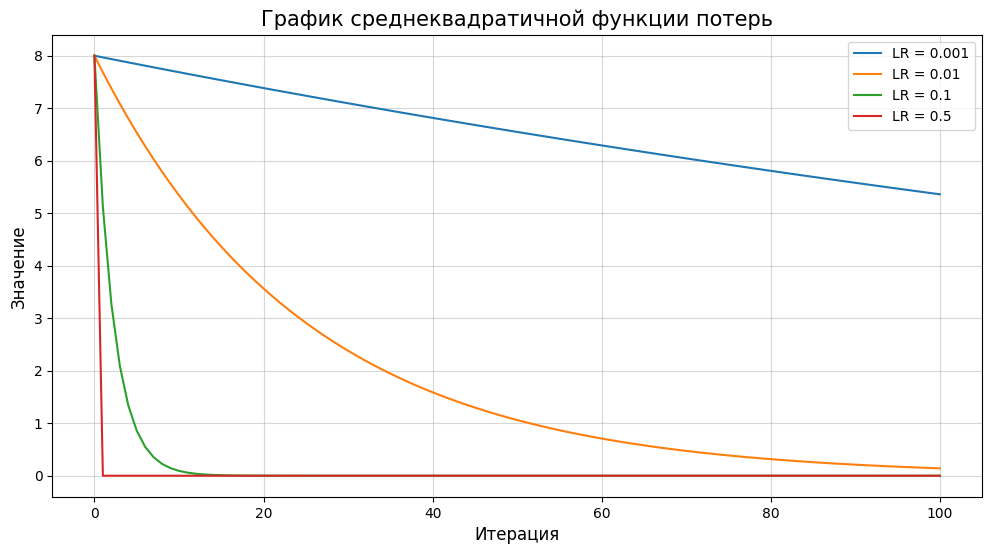

In [64]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
n_iter = 100
initial_point = np.array([2.0, 2.0])

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    gd = GradientDescent(learning_rate=lr, n_iterations=n_iter)
    gd.fit(quadratic_loss, quadratic_grad, initial_point)

    plt.plot(gd.history['loss'], label=f'LR = {lr}')

plt.title('График среднеквадратичной функции потерь', fontsize=15)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

/tmp/ipython-input-1796033206.py:33: RuntimeWarning:

overflow encountered in scalar power

/tmp/ipython-input-1796033206.py:35: RuntimeWarning:

overflow encountered in scalar power

/tmp/ipython-input-1796033206.py:27: RuntimeWarning:

overflow encountered in scalar power

/tmp/ipython-input-1796033206.py:33: RuntimeWarning:

invalid value encountered in scalar subtract

/tmp/ipython-input-1796033206.py:35: RuntimeWarning:

invalid value encountered in scalar subtract

/tmp/ipython-input-1796033206.py:27: RuntimeWarning:

invalid value encountered in scalar subtract

/tmp/ipython-input-1796033206.py:33: RuntimeWarning:

overflow encountered in scalar multiply

/tmp/ipython-input-147301805.py:44: RuntimeWarning:

invalid value encountered in subtract



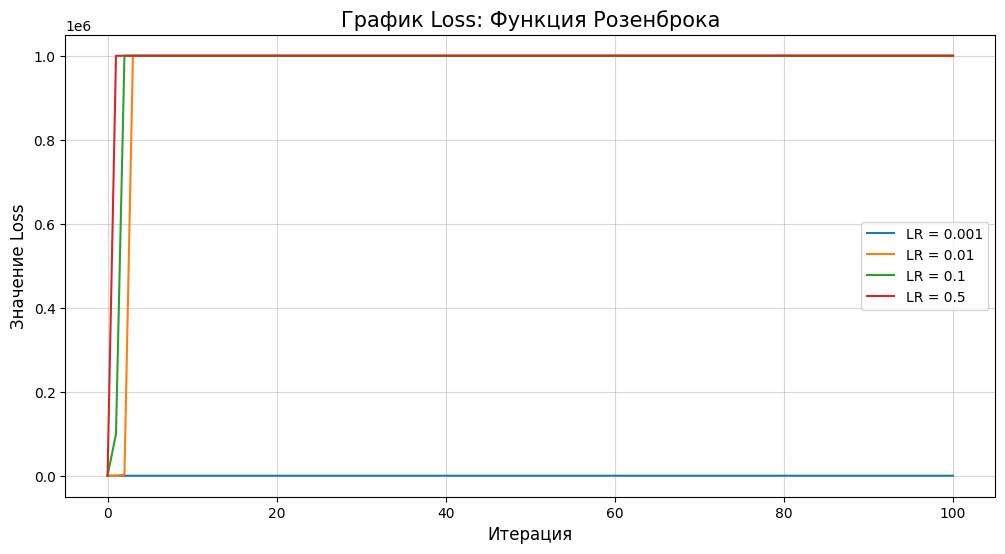

In [65]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
n_iter = 100
initial_point = np.array([-0.5, 0.5])

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    gd = GradientDescent(learning_rate=lr, n_iterations=n_iter)
    gd.fit(rosenbrock_loss, rosenbrock_grad, initial_point)

    # Gemini подсказал мне, что можно ограничить
    # значения для графика, так как при непрерывном росте
    # градиента числа становятся гигантскими
    loss_history = [val if val < 1e6 else 1e6 for val in gd.history['loss']]

    plt.plot(loss_history, label=f'LR = {lr}')

plt.title('График Loss: Функция Розенброка', fontsize=15)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('Значение Loss', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

По сути, график показывает то же самое, что мы видели и в числах: ошибка улетает в бесконечность. Так как, как мы уже выяснили, lr > ~0.005, почти невозможно работать с этим лоссом и как-либо его анализировать.

Для демонстрации построим дополнительный график с чуть более подходящими lr.

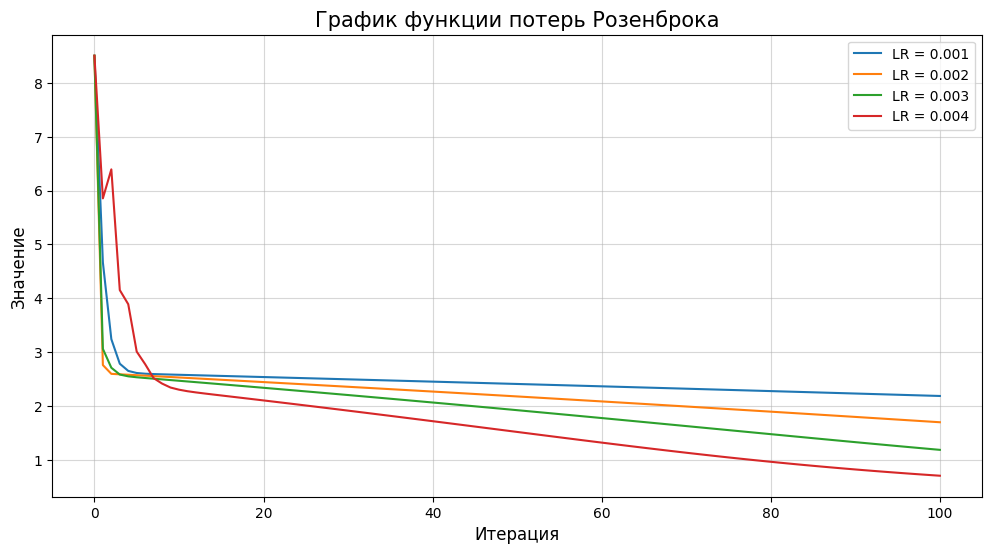

In [66]:
learning_rates = [0.001, 0.002, 0.003, 0.004]
n_iter = 100
initial_point = np.array([-0.5, 0.5])

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    gd = GradientDescent(learning_rate=lr, n_iterations=n_iter)
    gd.fit(rosenbrock_loss, rosenbrock_grad, initial_point)

    # Ограничим значения для графика, так как при взрыве градиента числа становятся гигантскими
    loss_history = [val if val < 1e6 else 1e6 for val in gd.history['loss']]

    plt.plot(loss_history, label=f'LR = {lr}')

plt.title('График функции потерь Розенброка', fontsize=15)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

**Ваши выводы здесь.**

**1. Квадратичная функция:**
*   **Нормальное поведение:** При `LR = 0.1` и `0.01` график выглядит хорошо — плавная кривая, которая быстро падает вниз и выходит на плато около нуля. Это значит, что лосс **сошелся**.
*   **Медленное поведение:** При `LR = 0.001` график тоже падает плавно, но очень медленно. За 100 шагов он не успевает дойти до нуля. Формально он сходится, но слишком долго.
*   **Странное поведение:** При `LR = 0.5` лосс падает почти мгновенно. Это эффективно, но в более сложных задачах такой большой шаг мог бы быть опасен тем, что мы можем перепрыгнуть минимум.

**2. Функция Розенброка:**
*   **Плохое поведение:** При `LR = 0.1` и `0.5` мы видим, что линия лосса мгновенно улетает в бесконечность (на графике она обрывается или уходит в максимум). Это классический обучения — шаг слишком велик для такого крутого рельефа. Лосс **не сошелся**.
*   **Застревание:** При `LR = 0.001` график сначала быстро падает, а потом становится почти плоским. Кажется, что он сошелся, но на самом деле мы просто попали на пологое дно графика и движемся по нему крайне медленно.
*   **Сравнение:** Если на квадратичной функции `LR = 0.1` был идеальным, то здесь он всё портит. Это доказывает, что для сложных функций нужно выбирать шаг гораздо осторожнее.

**Итоговый вывод:**
Лосс считается сошедшимся только на маленьких шагах для обеих функций. Однако на функции Розенброка это плато обманчиво: мы можем выйти на него не потому, что нашли идеальный минимум, а потому, что уклон стал слишком слабым и нашего шага не хватает, несмотря на то, что мы ещё относительно далеко от нуля, чтобы двигаться дальше по оврагу.

### **Задание 4. Расписания для learning rate и победа над бананами (3 балла)**

В предыдущих заданиях мы рассматривали градиентный спуск с постоянным шагом обучения

$$w_{k+1} = w_k - \eta\nabla L(w_k),$$
где $\eta$ (learning rate) — фиксированная константа. Но графики функций выше вблизи минимумов наталкивают на ледующую интуицию (встречающуюся очень часто) —  в начале обучения продуктивнее делать большие шаги, чтобы быстро “спуститься” с вершины/плато, ближе к минимуму шаг нужно уменьшать, чтобы не перепрыгнуть минимум.

Чтобы реализовать эту идею, на практике почти всегда используют расписание для шага обучения (learning rate schedules): $\eta$ делают зависящим от номера итерации:

$$\eta_k = \eta(k), \quad k = 0, 1, 2, \dots$$

Даже в самых сложных модификациях градиентного спуска (Momentum, Adam, Adagrad, RMSProp и т.п.) всегда есть базовый learning rate ((\eta), (\alpha)) и “соседние” гиперпараметры, которые управляют эффективным шагом, так что идея “шаг со временем меняется” присутствует всегда, даже если она спрятана в более сложной формуле.

**Варианты расписаний:**

1. **Step decay (ступенчатое уменьшение):**
   $$
   \eta_k =
   \begin{cases}
   \eta_0, & k < k_1, \\
   \eta_0 \cdot \gamma, & k_1 \le k < k_2 \\
   \eta_0 \cdot \gamma^2, & k \ge k_2.
   \end{cases}
   $$

2. **Exponential decay:**
   
   $$\eta_k = \eta_0 \cdot \gamma^k, \quad 0 < \gamma < 1.$$

3. **Inverse time decay:**
   $$\eta_k = \frac{\eta_0}{1 + \lambda k}.$$

и на самом деле — безумно много других — cosine decay, warm restarts и т.п.. Вам не нужно их заучивать, но важно их знать, чтобы понимать, как улучшать свои решения. Поэтому давайте сделаем простое расписание своими руками.

#### **4.1 Реализация расписания (1.5 балла)**

1. **Модифицируйте класс `GradientDescent`** так, чтобы он поддерживал **расписание шага обучения — inverse time decay**.



In [67]:
class GradientDescentWithScheduler:
    """
    Градиентный спуск с опциональным расписанием learning rate.

    Параметры
    ---------
    learning_rate : float — базовый шаг обучения η_0.
    n_iterations : int — число итераций.
    decay : float или None
        если decay is None — шаг обучения постоянный: η_k = η_0.
        если decay > 0 — inverse time decay:
            η_k = η_0 / (1 + decay * k),
        где k — номер итерации (0, 1, 2, ...).

    Пример вызовы:
    -------
    # постоянный шаг
    gd_const = GradientDescentWithScheduler(learning_rate=0.01, n_iterations=1000)

    # убывающий шаг
    gd_decay = GradientDescentWithScheduler(learning_rate=0.01, n_iterations=1000, decay=0.001)
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000, decay=None):
        self.learning_rate = float(learning_rate)
        self.n_iterations = int(n_iterations)
        self.decay = decay # ваш код здесь

        # сюда будем сохранять историю обучения
        self.history = {}

    def fit(self, loss_fn, grad_fn, initial_params):
        """
        Запустить градиентный спуск.

        Параметры
        ---------
        loss_fn : callable
            Функция потерь L(w): np.array -> float.
        grad_fn : callable
            Градиент ∇L(w): np.array - np.array той же размерности.
        initial_params : array-like
            Начальный вектор параметров w_0.

        Возвращает
        params : np.ndarray
            Финальные параметры после n_iterations.
        """
        params = np.array(initial_params, dtype=float)

        params_history = []
        loss_history = []
        lr_history = []

        for k in range(self.n_iterations):
            # шаг обучения на текущей итерации
            if self.decay is None:
                # сначала просто подставялем переданный при создании
                # экземпляра класса
                lr_k = self.learning_rate
            else:
                # на следующих итерациях будем использовать
                # обратно пропорциональный числу итераций lr с коэффициентом
                lr_k = self.learning_rate / (1 + self.decay * k)

            grad = grad_fn(params)

            # params = # ваш код

            # здесь я бы хотел обновлять параметры
            # после их сохранения. При обратной логике, как минимум,
            # теряется нулевая точка, а как максимум нарушается логика
            # записи. Если мы сначала обновим params, а потом сохраним
            # их вместе с loss, который был посчитан по старым
            # параметрам, у нас возникнет рассинхрон.
            # На графике точка будет стоять в одном месте
            # а лосс будет соответствовать другому месту.

            loss = loss_fn(params)

            params_history.append(params.copy()) # вот тут очень важно
            # делать копию. Иначе мы будем менять координаты внутри
            # одного и того же списка (по одной ссылке)
            loss_history.append(loss)
            lr_history.append(lr_k)

            params = params - lr_k * grad

        self.history = {
            "params": params_history,
            "loss": loss_history,
            "lr": lr_history
        }
        return params


#### **4.2 Победа над сложным минимумом (1.5 балла)**

1. **Сравните поведение градиентного спуска с постоянным lr и с расписанием lr** на функции Розенброка:

   * стартуйте из точки, фиксированной в коде с фиксрованным lr
   * запустите:

     * градиентный спуск с **постоянным** шагом $η = η_0$;
     * градиентный спуск с **убывающим** шагом $η_k$ (exponential decay или inverse time decay).

2. **Для каждого варианта:**

   * постройте 2D-контурный график функции Розенброка с траекторией;
   * постройте 3D-график ландшафта с траекторией;
   * постройте график значения loss по итерациям.

3. **Сделайте выводы. Опишите всё, что вы поняли о спуске из заданий.**

In [68]:
initial_point = np.array([0.3, 3])

# Подберите для этой точки оптимальный decay и lr, чтобы получить ошибку с расписанием < 0.05 (это реально)

lr = 0.003
decay = 0.001

# Постоянный learning rate
gd_const = GradientDescentWithScheduler(learning_rate=0.001, n_iterations=2000)
final_const = gd_const.fit(rosenbrock_loss, rosenbrock_grad, initial_point)

# Убывающий learning rate
gd_decay = GradientDescentWithScheduler(learning_rate=lr, n_iterations=2000, decay=decay)
final_decay = gd_decay.fit(rosenbrock_loss, rosenbrock_grad, initial_point)

print("Постоянный lr: ", final_const, rosenbrock_loss(final_const))
print("С расписанием: ", final_decay, rosenbrock_loss(final_decay))

Постоянный lr:  [1.22889899 1.51099192] 0.05245861794338722
С расписанием:  [0.947236   0.89703811] 0.002788788830032817


Получилось подобрать просто вручную.

Глобально, подбираем ``decay`` так, чтобы к концу обучения шаг стал сопоставим с точностью, которую мы хотим получить. Если затухание будет слишком сильным, мы просто не дойдём до минимума. Если слишком слабым — не успеем стабилизироваться.

В данном случае:

На 1-й итерации шаг будет 100% от начального.

На 1000-й итерации шаг станет в 2 раза меньше

1/(1+0.001⋅1000)=0.5

На 2000-й итерации он станет в 3 раза меньше

1/(1+0.001⋅2000)=0.33

In [69]:
# Сетка для визуализации Розенброка
x_range = np.linspace(-2, 2, 300)
y_range = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(x_range, y_range)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

# Истории для наших двух вариантов GD
history_dict = {
    "Постоянный lr": gd_const.history,
    "Inverse time decay": gd_decay.history
}

# 2D-контуры + траектории
plot_gd_2d(
    x_range=x_range,
    y_range=y_range,
    Z=Z,
    history_dict=history_dict,
    title="Функция Розенброка: траектории GD (2D контуры)",
    start_points=[initial_point],
    min_point=(1.0, 1.0),
    contour_kwargs=dict(
        colorscale='Viridis',
        showscale=False,
        contours=dict(start=0, end=500, size=25),
        opacity=0.7
    )
)

# 3D-поверхность + траектории
plot_gd_3d(
    x_range=x_range,
    y_range=y_range,
    Z=Z,
    loss_fn=rosenbrock_loss,
    history_dict=history_dict,
    title="Функция Розенброка: траектории GD (3D ландшафт)",
    min_point=(1.0, 1.0)
)


**Общие выводы.**

1.  **Чувствительность к ландшафту:** Градиентный спуск очень сильно зависит от формы функции. На простых впадинах он работает идеально, но на узких искривленных оврагах, как у Розенброка, он становится нестабильным.
2.  **Опасность большого шага:** Слишком большой `lr` приводит не к быстрому обучению, а к (NaN), улёту в бесконечность или просто очень большие лоссы. Это происходит, когда шаг перекидывает нас через минимум в зону еще более крутого наклона.
3.  **Преимущество расписания:** Постоянный шаг заставляет нас выбирать между «безопасно, но очень медленно» и «быстро, но рискованно». Расписание решает эту проблему: мы начинаем быстро, пока мы далеко, и замедляемся, когда нужно проявить точность у минимума.
4.  **Дебаг и графики:** В процессе выполнения я увидел, что ошибки в коде или неверные параметры могут полностью сломать обучение. Умение читать графики лосса и траекторий помогает быстро понять, что именно пошло не так: мы застряли на месте (маленький шаг) или улетели (большой шаг).
5.  **Итог:** Градиентный спуск — это не просто метод оптимизации, а очень чувствительный к параметрам, настройкам, балансу между скоростью движения и стабильностью алгоритма.Расписания шага — это самый простой способ сделать этот баланс эффективным. Только при осознанном и умелом обращении он может быть масштабируемым и эффективным.

## **Бонус 0.25 балла**

Проанализируйте график лосс-функции ниже. Попробуйте сформулировать гипотезы:
- Что происходит?
- Что с этим делать?

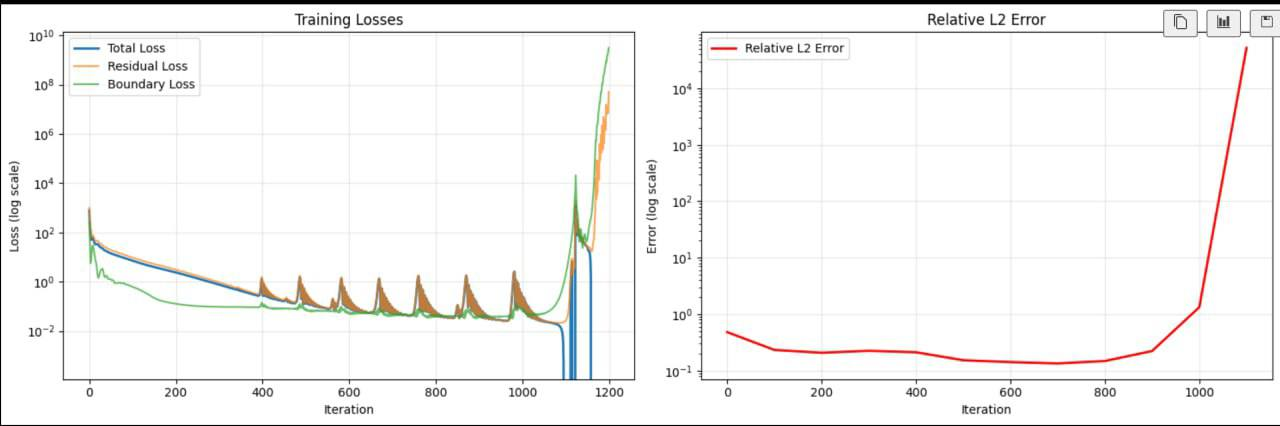

### 1. Что происходит? (Гипотезы)

*   **Перелет:** До 1000 итерации лосс падал, но видны скачки. Это значит, что шаг обучения уже тогда был на грани допустимого — модель билась о стенки узкого минимума. На 1100 итерации модель попала в зону очень крутого градиента, и слишком большой шаг выкинул параметры в область больших значений лосса.
*   **Неустойчивость:** Мы видим, что ошибка начала расти даже чуть раньше, чем взорвался лосс (примерно на 900 итерации). Это значит, что веса модели начали принимать неадекватные значения, что в итоге привело к  росту ошибки.

### 2. Что с этим делать?

*   **Использовать расписание:** Это именно то, что мы делали в задании 4. Нужно уменьшать Learning Rate со временем. Если бы на 1000 итерации шаг был в 10 раз меньше, «катапульты» бы не произошло.
*   **Отсечение:** Если градиент становится слишком огромным, мы принудительно ограничиваем его длину. Это не дает весам измениться слишком сильно за один шаг и спасает от NaN и неконтролируемого роста.
*   **Early Stopping:** По правому графику видно, что оптимальная точка обучения была в районе 600–800 итераций. После этого ошибка начала медленно расти. Стоило остановить обучение здесь, не дожидаясь взрыва.
*   **Адаптивные методы:** Использование оптимизаторов вроде **Adam** вместо обычного GD могло бы помочь, так как они сами подстраивают шаг под крутизну склона.